# Parameter Inference for Time-Dependent SIRS Model

We estimate parameters governing:

- Infection rate $\beta(t)$
- Immunity waning $\alpha(t)$

from observed infection data $I_{\text{obs}}(t)$.

We consider:

1. Deterministic inference (least squares)
2. Bayesian inference (posterior distributions)

---

## Model

$$
\begin{aligned}
\dot S &= -\beta(t) S I + \alpha(t) R \\
\dot I &= \beta(t) S I - \gamma I \\
\dot R &= \gamma I - \alpha(t) R
\end{aligned}
$$

---

## Goal

Estimate parameters:
- $B_i$, $\tau_i$, $\sigma_i$
- $\rho_i$

from data.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

In [13]:
gamma = 0.15
iota = 3

# initial guesses (to be estimated)
B = np.array([0.3, 0.3, 0.3])
tau = np.array([15, 60, 120])
sigma = np.array([3.0, 3.0, 2.5])

rho = np.array([0.05, 0.1, 0.1])

rho_0 = 0.01
B_0 = 0.05
sk = np.array([0.25, 0.25, 0.15])
T = np.array([30.5, 82.5, 144.5])

In [14]:
def alpha(t, rho):
    result = 0
    for i in range(len(rho)):
        result += rho[i] * ((1 + np.tanh(t - (T[i] - iota/2)))/2) \
                         * ((1 - np.tanh(t - (T[i] + iota/2)))/2)
    return rho_0 + result


def beta(t, B, tau, sigma):
    result = 0
    for i in range(len(B)):
        result += B[i] * np.exp(
            -0.5 * ((t - tau[i]) / (sigma[i] + sk[i]*(t - tau[i])))**2
        )
    return B_0 + result

In [15]:
def solve_sirs(t_eval, params):
    B = params[:3]
    tau = params[3:6]
    sigma = params[6:9]
    rho = params[9:12]

    def model(t, y):
        S, I, R = y
        return [
            -beta(t, B, tau, sigma) * S * I + alpha(t, rho) * R,
            beta(t, B, tau, sigma) * S * I - gamma * I,
            gamma * I - alpha(t, rho) * R
        ]

    y0 = [0.99, 0.01, 0.0]

    sol = solve_ivp(model, (t_eval[0], t_eval[-1]), y0, t_eval=t_eval)
    return sol.y[1]  # return I(t)

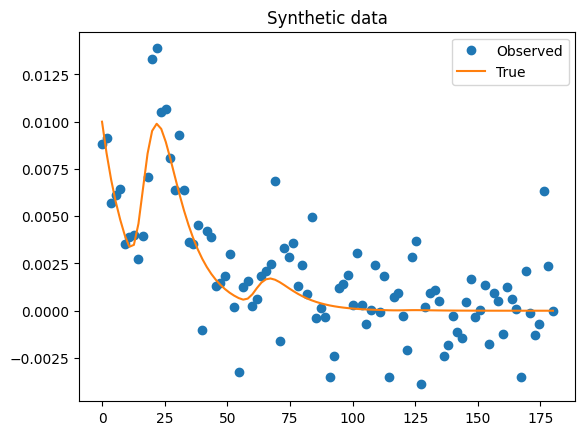

In [16]:
t_data = np.linspace(0, 180, 100)

true_params = np.concatenate([B, tau, sigma, rho])

I_true = solve_sirs(t_data, true_params)

# add noise
noise = 0.002 * np.random.randn(len(t_data))
I_obs = I_true + noise

plt.plot(t_data, I_obs, 'o', label='Observed')
plt.plot(t_data, I_true, label='True')
plt.legend()
plt.title("Synthetic data")
plt.show()

## Least Squares Fitting

In [ ]:
# Reducing the parameter space
tau_fixed = tau
sigma_fixed = sigma
rho_fixed = rho

# Only estimate B
initial_guess = B.copy()

Modifing Solver

In [18]:
def solve_sirs_reduced(t_eval, B_params):
    def model(t, y):
        S, I, R = y
        return [
            -beta(t, B_params, tau_fixed, sigma_fixed) * S * I + alpha(t, rho_fixed) * R,
            beta(t, B_params, tau_fixed, sigma_fixed) * S * I - gamma * I,
            gamma * I - alpha(t, rho_fixed) * R
        ]

    y0 = [0.99, 0.01, 0.0]

    sol = solve_ivp(
        model,
        (t_eval[0], t_eval[-1]),
        y0,
        t_eval=t_eval,
        method='RK23',       # faster
        rtol=1e-4,
        atol=1e-6
    )
    return sol.y[1]

In [19]:
def residuals(B_params):
    I_pred = solve_sirs_reduced(t_data, B_params)
    return I_pred - I_obs

In [20]:
lower_bounds = [0.0, 0.0, 0.0]
upper_bounds = [1.0, 1.0, 1.0]

In [28]:
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds),
    method='trf',
    max_nfev=200
)

params_est = result.x

In [30]:
print(params_est)
print(len(params_est))

[0.31771711 0.35998001 0.53712489]
3


In [31]:
I_fit = solve_sirs_reduced(t_data, params_est)

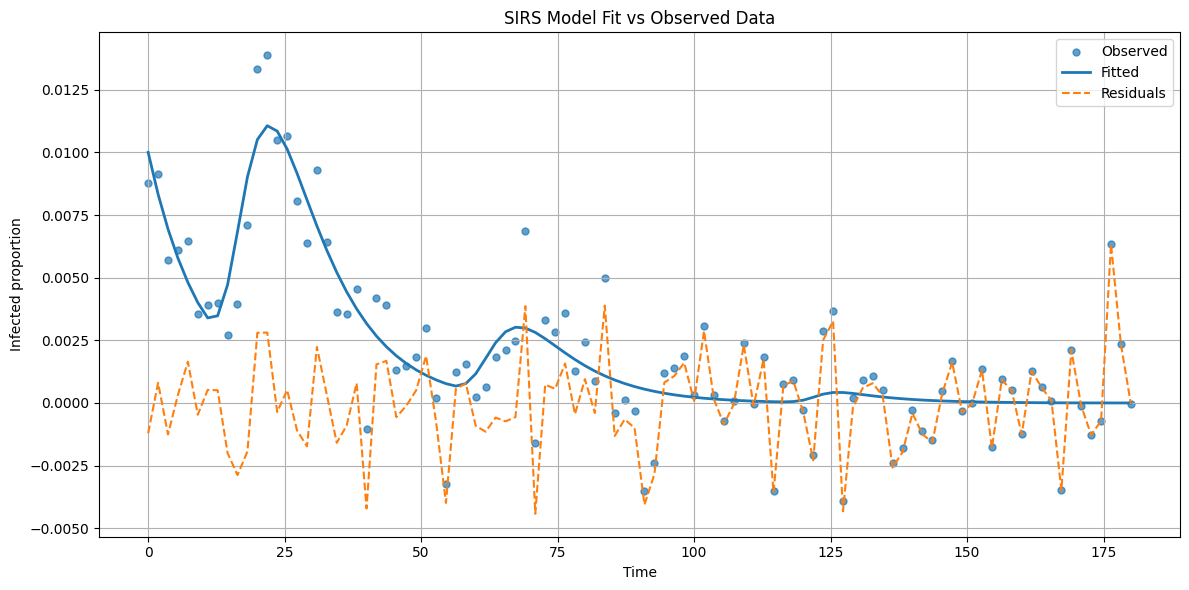

In [32]:
plt.figure(figsize=(12, 6))

# Observed data
plt.scatter(t_data, I_obs, s=25, alpha=0.7, label='Observed')

# Fitted curve
plt.plot(t_data, I_fit, linewidth=2, label='Fitted')

# Residuals (scaled for visualization)
residuals = I_obs - I_fit
plt.plot(t_data, residuals, linestyle='--', label='Residuals')

# Labels and formatting
plt.xlabel("Time")
plt.ylabel("Infected proportion")
plt.title("SIRS Model Fit vs Observed Data")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bayesian Inference (MCMC)

In [33]:
def log_likelihood(params):
    I_pred = solve_sirs(t_data, params)
    sigma_noise = 0.01
    return -0.5 * np.sum((I_obs - I_pred)**2 / sigma_noise**2)

In [34]:
def log_prior(params):
    # simple box constraints
    if np.any(params < 0) or np.any(params > 2):
        return -np.inf
    return 0.0

In [35]:
def log_posterior(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

MCMC Sampler

In [ ]:
def metropolis_hastings(init, n_samples=2000, step_size=0.01):
    samples = [init]
    current = init
    current_logp = log_posterior(current)

    for _ in range(n_samples):
        proposal = current + step_size * np.random.randn(len(init))
        proposal_logp = log_posterior(proposal)

        if np.log(np.random.rand()) < proposal_logp - current_logp:
            current = proposal
            current_logp = proposal_logp

        samples.append(current)

    return np.array(samples)

In [ ]:
samples = metropolis_hastings(params_est, n_samples=3000)

Posterior visualization

In [ ]:
plt.plot(samples[:, 0])
plt.title("Trace of B[0]")
plt.show()

## Interpretation

- Least squares provides point estimates.
- Bayesian inference provides uncertainty quantification.
- Posterior spread indicates identifiability of parameters.

Key challenges:
- Strong parameter correlations
- Nonlinearity of the forward model
- Identifiability issues in $\beta(t)$ and $\alpha(t)$